In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler

This section loads the NRI data, SVI data, shapefile, and NRI data dictionary. The NRI files give hazard risk information, the SVI files give social vulnerability information, and the shapefile provides the census tract boundaries needed for maps.

In [83]:
# Reading csv's and shapefile
ca_nri = pd.read_csv("NRI_Table_CensusTracts_California.csv")
ca_svi = pd.read_csv("California.csv")

co_nri = pd.read_csv("NRI_Table_CensusTracts_Colorado.csv")
co_svi = pd.read_csv("Colorado.csv")

tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
tracts = tracts.replace(-9999, np.nan)

nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

This part creates a common column called STCNTY in both the NRI and SVI datasets. Since both datasets need the same key to merge correctly, the code converts those columns to strings and removes duplicate SVI county records.

In [84]:
# Prepare merge keys
ca_nri['STCNTY'] = ca_nri['STCOFIPS'].astype(str)
co_nri['STCNTY'] = co_nri['STCOFIPS'].astype(str)
ca_svi['STCNTY'] = ca_svi['STCNTY'].astype(str)
co_svi['STCNTY'] = co_svi['STCNTY'].astype(str)

# Remove duplicate keys from SVI
ca_svi_clean = ca_svi.drop_duplicates(subset='STCNTY')
co_svi_clean = co_svi.drop_duplicates(subset='STCNTY')

# Merge
ca_complete_data = pd.merge(
    ca_nri, ca_svi_clean, on='STCNTY', suffixes=('', '_right'), validate='many_to_one'
)

co_complete_data = pd.merge(
    co_nri, co_svi_clean, on='STCNTY', suffixes=('', '_right'), validate='many_to_one'
)

This section identifies all numeric columns in the California and Colorado datasets. Missing values are filled using the median of each column so the calculations do not fail because of blank values.

In [85]:
# Colorado numeric columns
co_num_cols = co_complete_data.select_dtypes(include=["int64", "float64"]).columns

# California numeric columns
ca_num_cols = ca_complete_data.select_dtypes(include=["int64", "float64"]).columns

# Fill NA with median
co_complete_data[co_num_cols] = co_complete_data[co_num_cols].fillna(
    co_complete_data[co_num_cols].median()
)

ca_complete_data[ca_num_cols] = ca_complete_data[ca_num_cols].fillna(
    ca_complete_data[ca_num_cols].median()
)

This section removes duplicate census tract records using the TRACTFIPS column. This is important because each census tract should only appear once in the analysis and maps.

In [86]:
# This was used to fix a warning of the files being fragmented
ca_complete_data = ca_complete_data.drop_duplicates(subset="TRACTFIPS").copy()
co_complete_data = co_complete_data.drop_duplicates(subset="TRACTFIPS").copy()

This section prints the descriptions of the main fields used in the analysis. It helps confirm the meaning of variables related to wildfire risk, flood risk, social vulnerability, and resilience.

In [87]:
# This prints the descriptions of all the fields we will use in analysis
print(
    nri_dictionary[
        nri_dictionary["Field Name"].str.contains(
            "WFIR_RISKS|WFIR_EXPT|WFIR_AFREQ|WFIR_HLRP|"
            "RFLD_RISKS|RFLD_EXPT|RFLD_AFREQ|RFLD_HLRP|"
            "SOVI_SCORE|RESL_SCORE",
            na=False
        )
    ][["Field Name", "Field Alias"]]
)

     Field Name                                        Field Alias
35   SOVI_SCORE                       Social Vulnerability - Score
38   RESL_SCORE                       Community Resilience - Score
296  RFLD_AFREQ           Riverine Flooding - Annualized Frequency
301   RFLD_EXPT               Riverine Flooding - Exposure - Total
304   RFLD_HLRP  Riverine Flooding - Historic Loss Ratio - Popu...
319  RFLD_RISKS   Riverine Flooding - Hazard Type Risk Index Score
418  WFIR_AFREQ                    Wildfire - Annualized Frequency
423   WFIR_EXPT                        Wildfire - Exposure - Total
426   WFIR_HLRP        Wildfire - Historic Loss Ratio - Population
441  WFIR_RISKS            Wildfire - Hazard Type Risk Index Score


This section calculates the new wildfire risk score for California. Social vulnerability and resilience are normalized, then wildfire hazard is calculated using exposure, annual frequency, and historic loss ratio. The final risk score gives 40% weight to hazard, 45% to social vulnerability, and subtracts 15% for resilience.

In [89]:
# California Risk Calculations

ca_complete_data["SOVI_norm"] = scaler.fit_transform(ca_complete_data[["SOVI_SCORE"]])
ca_complete_data["RESL_norm"] = scaler.fit_transform(ca_complete_data[["RESL_SCORE"]])


ca_complete_data["WFIR_hazard_raw"] = (
    ca_complete_data["WFIR_EXPT"] *
    ca_complete_data["WFIR_AFREQ"] *
    ca_complete_data["WFIR_HLRP"]
)


ca_complete_data["WFIR_hazard_raw"] = ca_complete_data["WFIR_hazard_raw"].fillna(
    ca_complete_data["WFIR_hazard_raw"].median()
)


ca_complete_data["WFIR_hazard_norm"] = scaler.fit_transform(
    ca_complete_data[["WFIR_hazard_raw"]]
)


ca_complete_data["new_WFIR_RISKS"] = (
    0.40 * ca_complete_data["WFIR_hazard_norm"] +
    0.45 * ca_complete_data["SOVI_norm"] -
    0.15 * ca_complete_data["RESL_norm"]
).clip(lower=0)


ca_complete_data["new_WFIR_RISKS"] = scaler100.fit_transform(
    ca_complete_data[["new_WFIR_RISKS"]]
)


ca_tracts_clean = tracts.to_crs("ESRI:102003")
ca_tracts_clean["TRACTFIPS"] = ca_tracts_clean["TRACTFIPS"].astype(str)
ca_complete_data["TRACTFIPS"] = ca_complete_data["TRACTFIPS"].astype(str)

ca_tracts_clean = ca_tracts_clean.merge(
    ca_complete_data[["TRACTFIPS", "WFIR_RISKS", "new_WFIR_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

In [90]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaler100 = MinMaxScaler(feature_range=(0,100))

This section calculates the new cold wave risk score for Colorado. It normalizes social vulnerability and resilience, calculates cold wave hazard, fills missing values, and then creates a new risk score using the same weighted equation.

In [92]:
# Colorado Risk Calculations

# Normalize SOVI and RESL
co_complete_data["SOVI_norm"] = scaler.fit_transform(co_complete_data[["SOVI_SCORE"]])
co_complete_data["RESL_norm"] = scaler.fit_transform(co_complete_data[["RESL_SCORE"]])

# Cold Wave hazard calculation
co_complete_data["CWAV_hazard_raw"] = (
    co_complete_data["CWAV_EXPT"] *
    co_complete_data["CWAV_AFREQ"] *
    co_complete_data["CWAV_HLRP"]
)

# Fill NA values
co_complete_data["CWAV_hazard_raw"] = co_complete_data["CWAV_hazard_raw"].fillna(
    co_complete_data["CWAV_hazard_raw"].median()
)

# Normalize to 0–1
co_complete_data["CWAV_hazard_norm"] = scaler.fit_transform(
    co_complete_data[["CWAV_hazard_raw"]]
)

# Risk equation
co_complete_data["new_CWAV_RISKS"] = (
    0.40 * co_complete_data["CWAV_hazard_norm"] +
    0.45 * co_complete_data["SOVI_norm"] -
    0.15 * co_complete_data["RESL_norm"]
).clip(lower=0)

# Scale to 0–100
co_complete_data["new_CWAV_RISKS"] = scaler100.fit_transform(
    co_complete_data[["new_CWAV_RISKS"]]
)

# Prepare for mapping
co_tracts_clean = tracts.to_crs("ESRI:102003")
co_tracts_clean["TRACTFIPS"] = co_tracts_clean["TRACTFIPS"].astype(str)
co_complete_data["TRACTFIPS"] = co_complete_data["TRACTFIPS"].astype(str)

# Merge for plotting
co_tracts_clean = co_tracts_clean.merge(
    co_complete_data[["TRACTFIPS", "CWAV_RISKS", "new_CWAV_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

This section cleans the TRACTFIPS values so the tract IDs match correctly between the shapefile and the risk dataset. It removes extra decimals, removes spaces, and makes sure each ID has 11 digits.

In [93]:
# Clean TRACTFIPS in both dataframes
ca_complete_data["TRACTFIPS"] = (
    ca_complete_data["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

ca_tracts_clean["TRACTFIPS"] = (
    ca_tracts_clean["TRACTFIPS"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(11)
)

This section prepares the California shapefile for mapping. It changes the map projection, makes sure the tract IDs are stored as text, and merges the wildfire risk scores into the shapefile.

In [94]:
# Prepare shapefile for California
ca_tracts_clean = tracts.to_crs("ESRI:102003")

# Make sure keys match
ca_tracts_clean["TRACTFIPS"] = ca_tracts_clean["TRACTFIPS"].astype(str)
ca_complete_data["TRACTFIPS"] = ca_complete_data["TRACTFIPS"].astype(str)

# Merge California data into shapefile
ca_tracts_clean = ca_tracts_clean.merge(
    ca_complete_data[["TRACTFIPS", "WFIR_RISKS", "new_WFIR_RISKS"]],
    on="TRACTFIPS",
    how="left"
)

This section groups the California wildfire results by county and calculates the average NRI score and the average new risk score. It then selects the top 10 highest-risk counties and bottom 10 lowest-risk counties.

In [97]:
# Group by county
ca_counties_fire = ca_complete_data.groupby('COUNTY')[['WFIR_RISKS', 'new_WFIR_RISKS']].mean()

# Top 10 counties (highest wildfire risk)
ca_counties_fire_top = ca_counties_fire.nlargest(10, 'new_WFIR_RISKS')

# Bottom 10 counties (lowest wildfire risk)
ca_counties_fire_bottom = ca_counties_fire.nsmallest(10, 'new_WFIR_RISKS')

# (optional) view results
#print(ca_counties_fire_top)
#print(ca_counties_fire_bottom)

This section creates two bar charts comparing the original NRI wildfire score and the new wildfire score. One chart shows the 10 highest-risk counties, and the other chart shows the 10 lowest-risk counties.

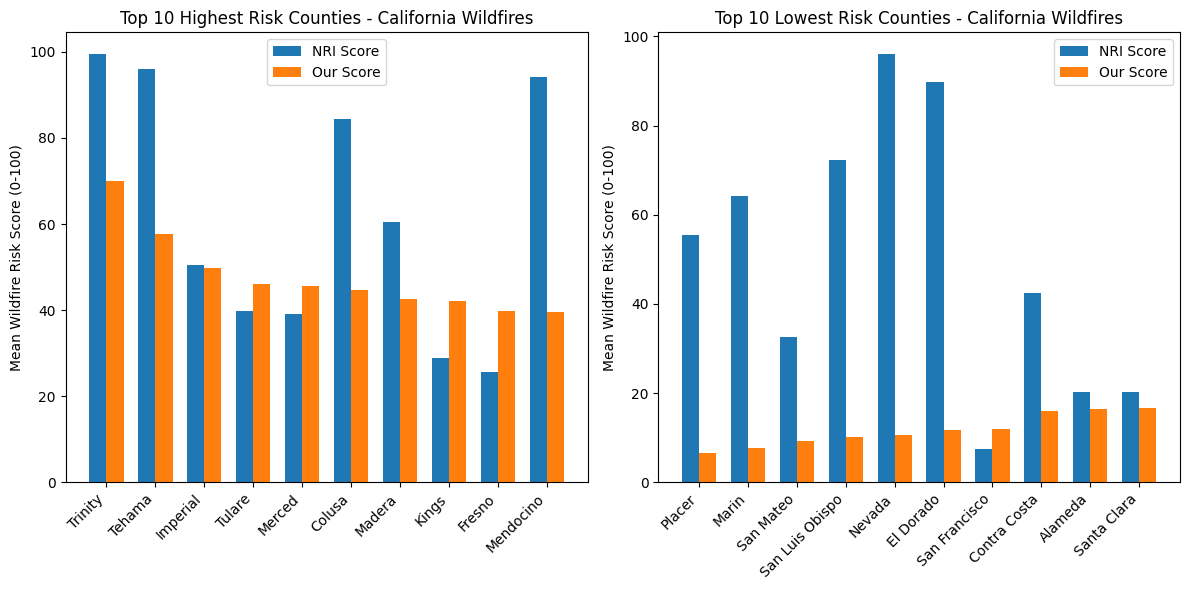

In [98]:
# Group by counties using correct dataframe
ca_counties_fire = ca_complete_data.groupby('COUNTY')[['WFIR_RISKS', 'new_WFIR_RISKS']].mean()

# Top 10 and bottom 10
ca_counties_fire_top = ca_counties_fire.nlargest(10, 'new_WFIR_RISKS')
ca_counties_fire_bottom = ca_counties_fire.nsmallest(10, 'new_WFIR_RISKS')

# Plot setup
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

width = 0.35

# Top 10 highest risk counties
x = np.arange(len(ca_counties_fire_top))
axes[0].bar(x - width/2, ca_counties_fire_top["WFIR_RISKS"], width, label="NRI Score")
axes[0].bar(x + width/2, ca_counties_fire_top["new_WFIR_RISKS"], width, label="Our Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ca_counties_fire_top.index, rotation=45, ha='right')
axes[0].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - California Wildfires")
axes[0].legend()

# Top 10 lowest risk counties
x = np.arange(len(ca_counties_fire_bottom))
axes[1].bar(x - width/2, ca_counties_fire_bottom["WFIR_RISKS"], width, label="NRI Score")
axes[1].bar(x + width/2, ca_counties_fire_bottom["new_WFIR_RISKS"], width, label="Our Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ca_counties_fire_bottom.index, rotation=45, ha='right')
axes[1].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - California Wildfires")
axes[1].legend()

plt.tight_layout()
plt.show()

This section searches the California map dataframe for flood-related columns. This helps identify the correct column name to use when creating flood risk maps.

In [99]:
# See the actual flood columns in your map dataframe
print([col for col in ca_tracts_clean.columns if "FLD" in col])

['CFLD_EVNTS', 'CFLD_AFREQ', 'CFLD_EXP_A', 'CFLD_EXPB', 'CFLD_EXPP', 'CFLD_EXPPE', 'CFLD_EXPT', 'CFLD_HLRB', 'CFLD_HLRP', 'CFLD_HLRR', 'CFLD_EALB', 'CFLD_EALP', 'CFLD_EALPE', 'CFLD_EALT', 'CFLD_EALS', 'CFLD_EALR', 'CFLD_ALRB', 'CFLD_ALRP', 'CFLD_ALR_N', 'CFLD_RISKV', 'CFLD_RISKS', 'CFLD_RISKR', 'RFLD_EVNTS', 'RFLD_AFREQ', 'RFLD_EXP_A', 'RFLD_EXPB', 'RFLD_EXPP', 'RFLD_EXPPE', 'RFLD_EXPA', 'RFLD_EXPT', 'RFLD_HLRB', 'RFLD_HLRP', 'RFLD_HLRA', 'RFLD_HLRR', 'RFLD_EALB', 'RFLD_EALP', 'RFLD_EALPE', 'RFLD_EALA', 'RFLD_EALT', 'RFLD_EALS', 'RFLD_EALR', 'RFLD_ALRB', 'RFLD_ALRP', 'RFLD_ALRA', 'RFLD_ALR_N', 'RFLD_RISKV', 'RFLD_RISKS', 'RFLD_RISKR']


This section creates two side-by-side maps for California flood risk. The first map shows the National Risk Index flood score, while the second map is labeled as the project’s risk index score.

Flood columns found: ['RFLD_EVNTS', 'RFLD_AFREQ', 'RFLD_EXP_A', 'RFLD_EXPB', 'RFLD_EXPP', 'RFLD_EXPPE', 'RFLD_EXPA', 'RFLD_EXPT', 'RFLD_HLRB', 'RFLD_HLRP', 'RFLD_HLRA', 'RFLD_HLRR', 'RFLD_EALB', 'RFLD_EALP', 'RFLD_EALPE', 'RFLD_EALA', 'RFLD_EALT', 'RFLD_EALS', 'RFLD_EALR', 'RFLD_ALRB', 'RFLD_ALRP', 'RFLD_ALRA', 'RFLD_ALR_N', 'RFLD_RISKV', 'RFLD_RISKS', 'RFLD_RISKR']


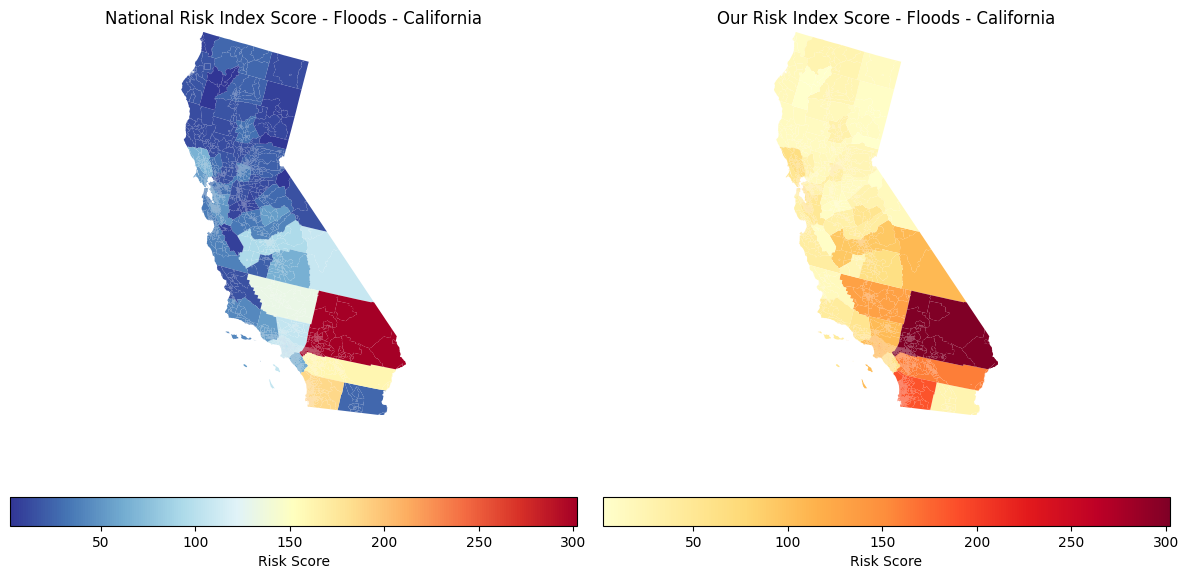

In [100]:
# Automatically find the correct NRI flood column
flood_cols = [col for col in ca_tracts_clean.columns if "RFLD" in col]

print("Flood columns found:", flood_cols)

# Pick the original NRI flood column
nri_flood_col = flood_cols[0]

# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "California"

state_map = ca_tracts_clean[
    ca_tracts_clean["STATE"].str.lower() == state_name.lower()
].copy()

# NRI Flood Risk
state_map.plot(column=nri_flood_col, ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Floods - California")
ax[0].set_axis_off()

# Our Flood Risk — use same flood column for now unless your new one exists
state_map.plot(column=nri_flood_col, ax=ax[1], legend=True,
                linewidth=0.1, cmap="YlOrRd",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Floods - California")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

This section creates a new flood risk score for California if it does not already exist. It calculates flood hazard using exposure, annual frequency, and historic loss ratio, then combines it with social vulnerability and resilience. The results are grouped by county and shown in bar charts for the highest and lowest flood risk counties.

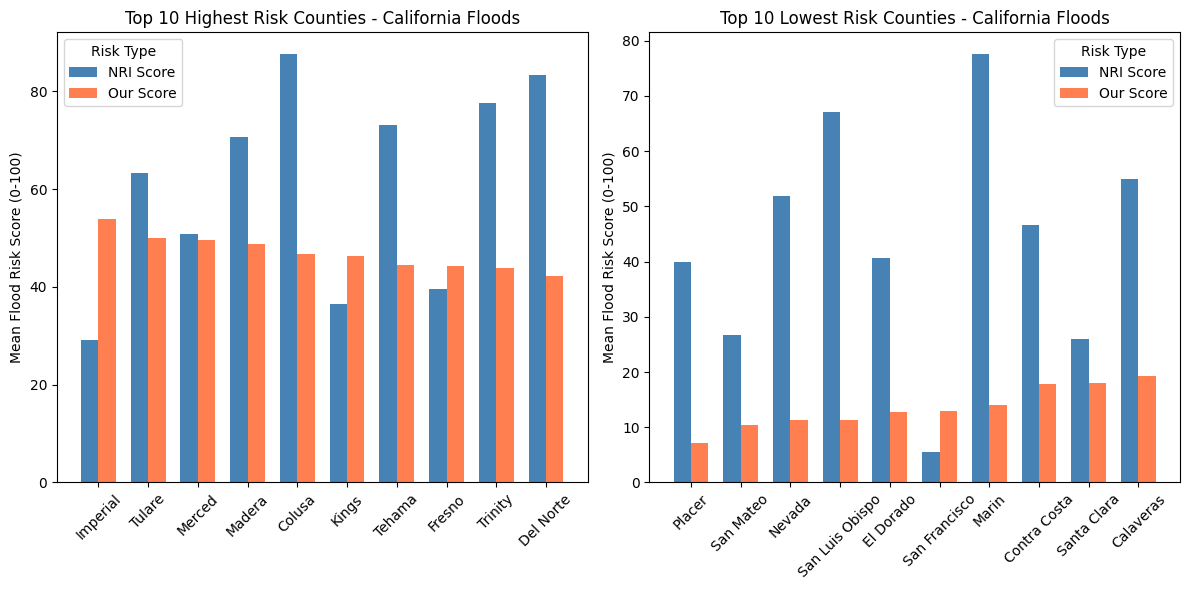

In [102]:
# Create new_RFLD_RISKS if it does not exist
if "new_RFLD_RISKS" not in ca_complete_data.columns:
    ca_complete_data["RFLD_hazard_raw"] = (
        ca_complete_data["RFLD_EXPT"] *
        ca_complete_data["RFLD_AFREQ"] *
        ca_complete_data["RFLD_HLRP"]
    )

    ca_complete_data["RFLD_hazard_raw"] = ca_complete_data["RFLD_hazard_raw"].fillna(
        ca_complete_data["RFLD_hazard_raw"].median()
    )

    ca_complete_data["RFLD_hazard_norm"] = scaler.fit_transform(
        ca_complete_data[["RFLD_hazard_raw"]]
    )

    ca_complete_data["new_RFLD_RISKS"] = (
        0.40 * ca_complete_data["RFLD_hazard_norm"] +
        0.45 * ca_complete_data["SOVI_norm"] -
        0.15 * ca_complete_data["RESL_norm"]
    ).clip(lower=0)

    ca_complete_data["new_RFLD_RISKS"] = scaler100.fit_transform(
        ca_complete_data[["new_RFLD_RISKS"]]
    )

# Group by county
ca_counties_fld = ca_complete_data.groupby('COUNTY')[['RFLD_RISKS', 'new_RFLD_RISKS']].mean()

# Top and bottom 10
ca_counties_fld_top = ca_counties_fld.nlargest(10, 'new_RFLD_RISKS')
ca_counties_fld_bottom = ca_counties_fld.nsmallest(10, 'new_RFLD_RISKS')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

x = np.arange(len(ca_counties_fld_top))
width = 0.35
axes[0].bar(x - width/2, ca_counties_fld_top["RFLD_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, ca_counties_fld_top["new_RFLD_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ca_counties_fld_top.index, rotation=45)
axes[0].set_ylabel("Mean Flood Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - California Floods")
axes[0].legend(title="Risk Type")

x = np.arange(len(ca_counties_fld_bottom))
axes[1].bar(x - width/2, ca_counties_fld_bottom["RFLD_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, ca_counties_fld_bottom["new_RFLD_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ca_counties_fld_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Flood Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - California Floods")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

This section creates two maps for Colorado wildfire risk. The first map shows the original NRI wildfire risk score, and the second map shows the new wildfire risk score if it is available.

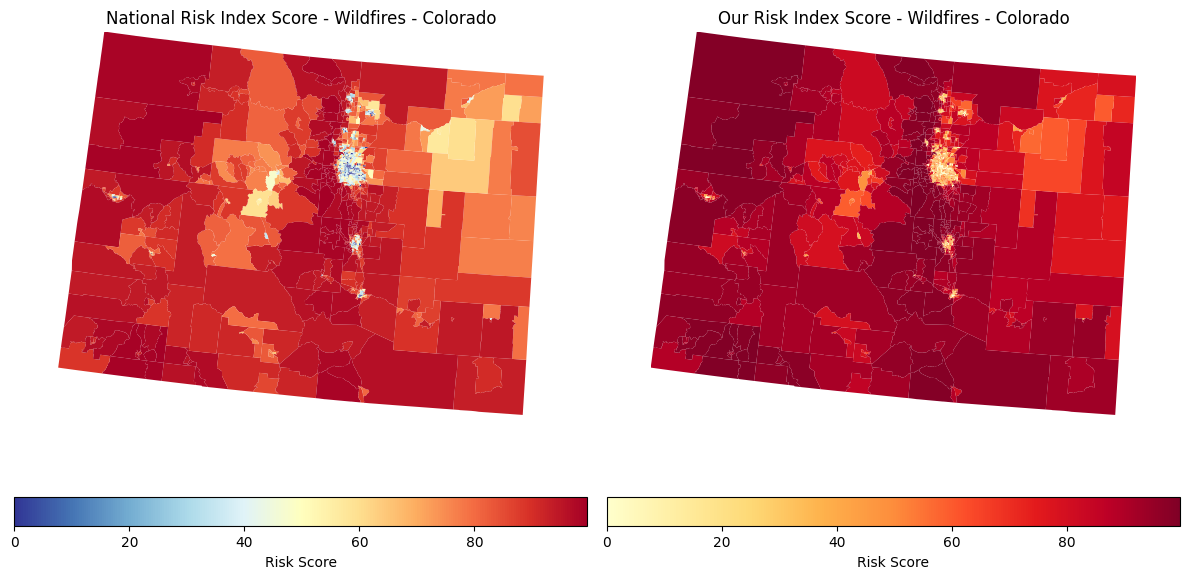

In [105]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

state_name = "Colorado"

state_map = co_tracts_clean[
    co_tracts_clean["STATE"].str.lower() == state_name.lower()
].copy()

# Fix column names safely
nri_cols = [c for c in state_map.columns if "WFIR_RISKS" in c and "new" not in c]
our_cols = [c for c in state_map.columns if "new_WFIR_RISKS" in c]

nri_col = nri_cols[0]
our_col = our_cols[0] if len(our_cols) > 0 else nri_col  # fallback if missing

# NRI Colorado Wildfire Risk
state_map.plot(column=nri_col, ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Wildfires - Colorado")
ax[0].set_axis_off()

# Our Colorado Wildfire Risk
state_map.plot(column=our_col, ax=ax[1], legend=True,
                linewidth=0.1, cmap="YlOrRd",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Wildfires - Colorado")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

This section creates the new Colorado wildfire risk score if it has not already been created. Then it groups the results by county and compares the NRI wildfire score with the new wildfire score using bar charts.

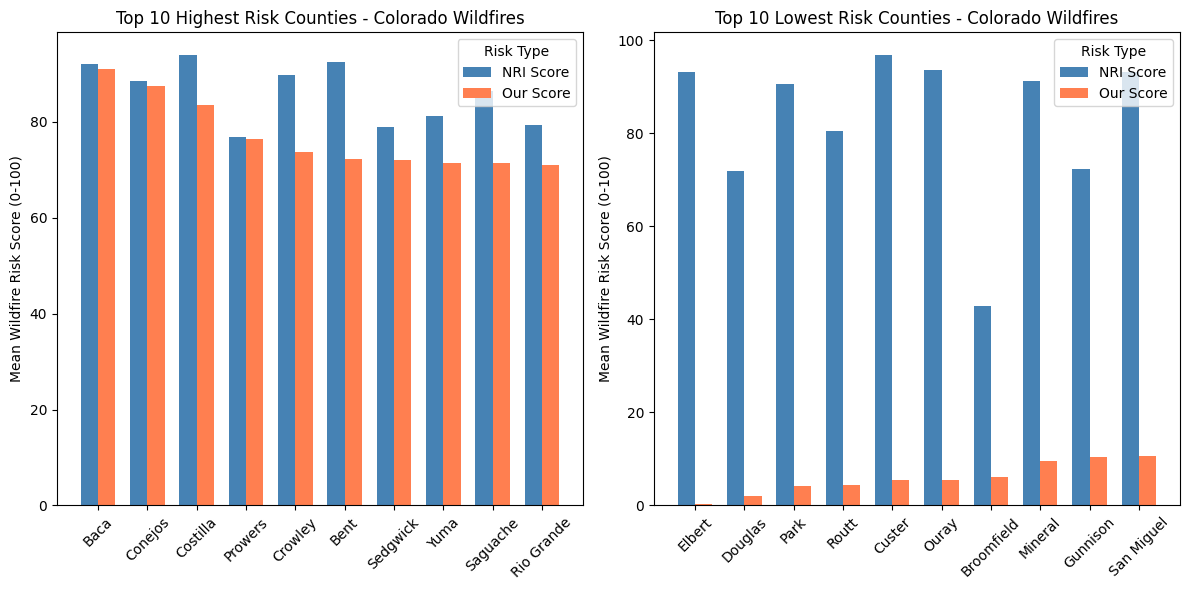

In [110]:
# Create new_WFIR_RISKS if it does not exist
if "new_WFIR_RISKS" not in co_complete_data.columns:
    co_complete_data["WFIR_hazard_raw"] = (
        co_complete_data["WFIR_EXPT"] *
        co_complete_data["WFIR_AFREQ"] *
        co_complete_data["WFIR_HLRP"]
    )

    co_complete_data["WFIR_hazard_raw"] = co_complete_data["WFIR_hazard_raw"].fillna(
        co_complete_data["WFIR_hazard_raw"].median()
    )

    co_complete_data["WFIR_hazard_norm"] = scaler.fit_transform(
        co_complete_data[["WFIR_hazard_raw"]]
    )

    co_complete_data["new_WFIR_RISKS"] = (
        0.40 * co_complete_data["WFIR_hazard_norm"] +
        0.45 * co_complete_data["SOVI_norm"] -
        0.15 * co_complete_data["RESL_norm"]
    ).clip(lower=0)

    co_complete_data["new_WFIR_RISKS"] = scaler100.fit_transform(
        co_complete_data[["new_WFIR_RISKS"]]
    )

# This groups the data by counties by the mean of the NRI risk and our risk
co_counties_fire = co_complete_data.groupby('COUNTY')[['WFIR_RISKS', 'new_WFIR_RISKS']].mean()

# These filter to top 10 and bottom 10
co_counties_fire_top = co_counties_fire.nlargest(10, 'new_WFIR_RISKS')
co_counties_fire_bottom = co_counties_fire.nsmallest(10, 'new_WFIR_RISKS')

# Makes plot space
fig, axes = plt.subplots(1,2,figsize=(12,6))

# Top 10 highest risk counties
x = np.arange(len(co_counties_fire_top))
width = 0.35
axes[0].bar(x - width/2, co_counties_fire_top["WFIR_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, co_counties_fire_top["new_WFIR_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(co_counties_fire_top.index, rotation=45)
axes[0].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Colorado Wildfires")
axes[0].legend(title="Risk Type")

# Bottom 10 lowest risk counties
x = np.arange(len(co_counties_fire_bottom))
axes[1].bar(x - width/2, co_counties_fire_bottom["WFIR_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, co_counties_fire_bottom["new_WFIR_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(co_counties_fire_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Wildfire Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Colorado Wildfires")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()

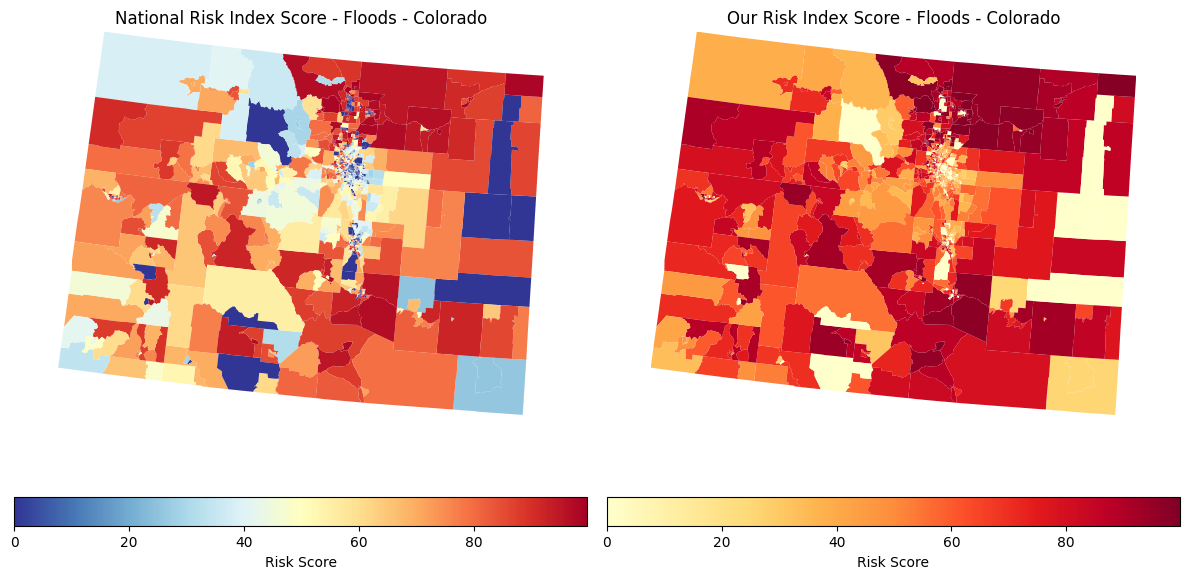

In [111]:
# Creates map space for 2 plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Selected state
state_name = "Colorado"

# Filters data to only include Colorado
state_map = co_tracts_clean[
    co_tracts_clean["STATE"].str.lower() == state_name.lower()
].copy()

# NRI Colorado Flood Risk
state_map.plot(column='RFLD_RISKS', ax=ax[0], legend=True,
                linewidth=0.1, cmap="RdYlBu_r",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

# Adjust bounds
minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax[0].set_xlim(minx-padding, maxx+padding)
ax[0].set_ylim(miny-padding, maxy+padding)
ax[0].set_title("National Risk Index Score - Floods - Colorado")
ax[0].set_axis_off()

# Our Colorado Flood Risk
# (uses same column unless you have new_RFLD_RISKS created)
state_map.plot(column='RFLD_RISKS', ax=ax[1], legend=True,
                linewidth=0.1, cmap="YlOrRd",
                legend_kwds={'label': "Risk Score", 'orientation': "horizontal"},
                missing_kwds={'color': "lightgrey", 'label': "No Data"})

ax[1].set_xlim(minx-padding, maxx+padding)
ax[1].set_ylim(miny-padding, maxy+padding)
ax[1].set_title("Our Risk Index Score - Floods - Colorado")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

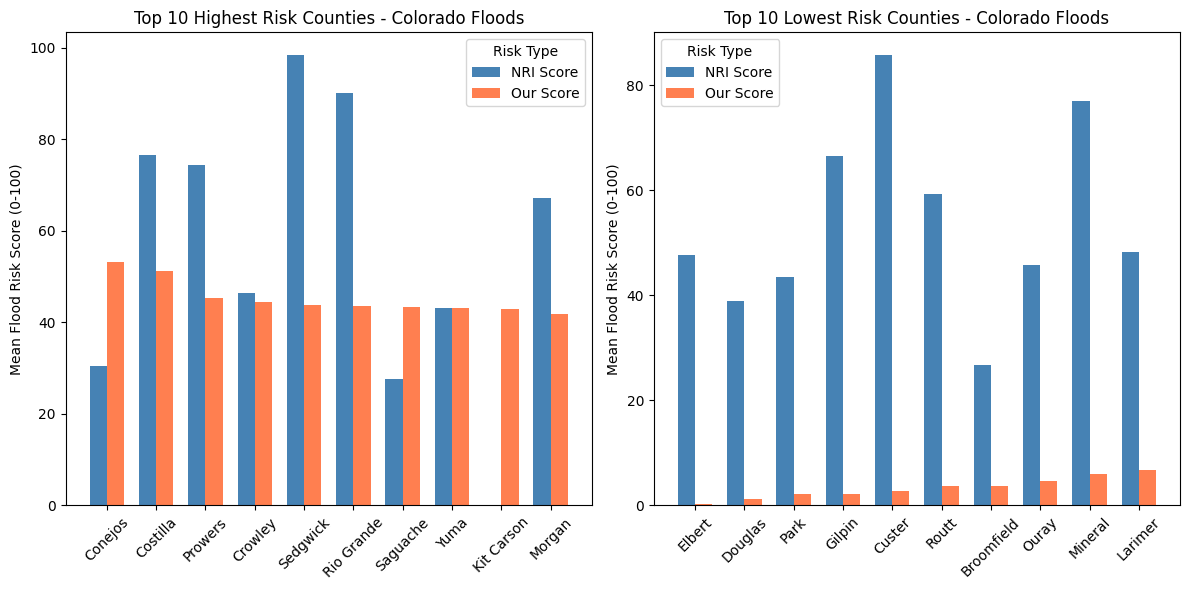

In [112]:
# Create our Colorado flood risk if it does not already exist
if "new_RFLD_RISKS" not in co_complete_data.columns:
    co_complete_data["RFLD_hazard_raw"] = (
        co_complete_data["RFLD_EXPT"] *
        co_complete_data["RFLD_AFREQ"] *
        co_complete_data["RFLD_HLRP"]
    )

    co_complete_data["RFLD_hazard_raw"] = co_complete_data["RFLD_hazard_raw"].fillna(
        co_complete_data["RFLD_hazard_raw"].median()
    )

    co_complete_data["RFLD_hazard_norm"] = scaler.fit_transform(
        co_complete_data[["RFLD_hazard_raw"]]
    )

    co_complete_data["new_RFLD_RISKS"] = (
        0.40 * co_complete_data["RFLD_hazard_norm"] +
        0.45 * co_complete_data["SOVI_norm"] -
        0.15 * co_complete_data["RESL_norm"]
    ).clip(lower=0)

    co_complete_data["new_RFLD_RISKS"] = scaler100.fit_transform(
        co_complete_data[["new_RFLD_RISKS"]]
    )

# This groups the data by counties by the mean of the NRI risk and our risk
co_counties_floods = co_complete_data.groupby('COUNTY')[['RFLD_RISKS', 'new_RFLD_RISKS']].mean()

# These filter to top 10 and bottom 10 so the bar chart is actually readable and not too congested
co_counties_floods_top = co_counties_floods.nlargest(10, 'new_RFLD_RISKS')
co_counties_floods_bottom = co_counties_floods.nsmallest(10, 'new_RFLD_RISKS')

# Makes plot space
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sets the arrangements and what variables are on which axis as well as labels and colors
x = np.arange(len(co_counties_floods_top))
width = 0.35
axes[0].bar(x - width/2, co_counties_floods_top["RFLD_RISKS"], width, label="NRI Score", color="steelblue")
axes[0].bar(x + width/2, co_counties_floods_top["new_RFLD_RISKS"], width, label="Our Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(co_counties_floods_top.index, rotation=45)
axes[0].set_ylabel("Mean Flood Risk Score (0-100)")
axes[0].set_title("Top 10 Highest Risk Counties - Colorado Floods")
axes[0].legend(title="Risk Type")

# Sets the arrangements and what variables are on which axis as well as labels and colors
x = np.arange(len(co_counties_floods_bottom))
axes[1].bar(x - width/2, co_counties_floods_bottom["RFLD_RISKS"], width, label="NRI Score", color="steelblue")
axes[1].bar(x + width/2, co_counties_floods_bottom["new_RFLD_RISKS"], width, label="Our Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(co_counties_floods_bottom.index, rotation=45)
axes[1].set_ylabel("Mean Flood Risk Score (0-100)")
axes[1].set_title("Top 10 Lowest Risk Counties - Colorado Floods")
axes[1].legend(title="Risk Type")

plt.tight_layout()
plt.show()